In [1]:
import time
import random
import os
import wfdb
import idx2numpy
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.io as sio

from pathlib import Path
from skimage import draw
from datetime import datetime
from math import log10, sqrt
from screenlib import util, model, optimizer, screening
from matplotlib import style
from matplotlib.ticker import LogLocator, FixedLocator, ScalarFormatter
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

In [2]:
sys.path.append(str(Path().resolve().parent))

import source.optimizer as optimizer
import source.model as model

In [3]:
plt.style.use('default')
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({'font.family': 'serif'})

x_ticks = [0.01,0.05,0.1,0.5,1.0]

In [4]:
np.random.seed(5)
random.seed(5)

# Loading dataset

In [5]:
tile_size = 28
MAX_UINT8_VAL = 255

In [6]:
dataset = np.load('../datasets/medmnist/adrenalmnist3d.npz')

In [7]:
y_imb_train = dataset['train_labels']
X_imb_train = dataset['train_images'].reshape(len(y_imb_train),tile_size**3)/MAX_UINT8_VAL

In [8]:
y_imb_val = dataset['val_labels']
X_imb_val = dataset['val_images'].reshape(len(y_imb_val), tile_size**3)/MAX_UINT8_VAL

In [9]:
y_imb_test = dataset['test_labels']
X_imb_test = dataset['test_images'].reshape(len(y_imb_test), tile_size**3)/MAX_UINT8_VAL

In [10]:
X_imb = np.vstack((X_imb_train, X_imb_val, X_imb_test))
y_imb = np.vstack((y_imb_train, y_imb_val, y_imb_test))

X_train_imb, X_test, y_train_imb, y_test = train_test_split(X_imb, y_imb, test_size=0.15, random_state=42, shuffle=True)

sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train_imb, y_train_imb)

In [11]:
Xt_train = np.float32(np.hstack((np.ones([X_train.shape[0], 1]), X_train)))
Xt_test  = np.float32(np.hstack((np.ones([X_test.shape[0], 1]), X_test)))

In [12]:
y_train = y_train.reshape(y_train.shape + (1,))

# Experiment

In [13]:
num_loops = 1
max_iter  = 10
tol       = 1e-16
eps       = np.finfo(float).eps
n_bins    = 32
n_points  = 20
mag_ord_start = -2
mag_ord_end = 0

In [14]:
lmb_r = np.float32(np.logspace(mag_ord_start, mag_ord_end, num=n_points, endpoint=False))

In [15]:
lmb_max = np.linalg.norm(np.matmul(Xt_train.T, 1/2-y_train, dtype=np.float32), ord=np.inf, axis=0)

In [16]:
lmb_vec = lmb_r*lmb_max

In [17]:
params_dict    = {}
functions_dict = {}
screening_dict = {}

In [18]:
time_min_vec  = []
time_mean_vec = []
time_max_vec  = []
acc_test_vec  = []
acc_train_vec = []
card_vec      = []
true_card_vec = []
supp_mat      = []

In [19]:
params_dict['ss']       = 0
params_dict['alpha']    = 5e-5
params_dict['max_iter'] = max_iter
params_dict['tol']      = tol
params_dict['c']        = 1
params_dict['k_dyn']    = 0
params_dict['k_skip']   = 5
params_dict['stop_crit'] = 1

In [20]:
functions_dict['f']       = model.binceloss
functions_dict['g']       = model.l1norm
functions_dict['df_du']   = model.grad_binceloss
functions_dict['prox_g']  = model.prox_l1norm
functions_dict['fc']      = model.binceloss_conj
functions_dict['L']       = 0.25
functions_dict['lmb_max'] = lmb_max

In [21]:
u_0 = np.zeros([Xt_train.shape[1],1], dtype=np.float32)

In [22]:
idx_global = np.arange(u_0.shape[0])

In [23]:
alphas_dict = {}

alphas_dict['alpha_0'] = 0.9
alphas_dict['alpha_1'] = 0.7
alphas_dict['alpha_2'] = 0.7
alphas_dict['alpha_3'] = 0.7
alphas_dict['alpha_4'] = 0.7

alphas_dict['skew_lim'] = 0.1

## Vanilla

In [24]:
params_dict['k_screening'] = 0

screening_dict['mode'] = 0
screening_dict['n_bins'] = n_bins
screening_dict['thresholding'] = 0

for lmb in lmb_vec:

  time_proc = np.zeros(num_loops, dtype=float)

  for k in range(num_loops):
    t_start = time.perf_counter()
    u_opt, _, meas, fun_costs = optimizer.apg_opt(y_train, Xt_train, lmb, u_0, params_dict, functions_dict, screening_dict, alphas_dict)
    t_end = time.perf_counter()
    time_proc[k] = t_end-t_start

  time_min  = np.min(time_proc)
  time_mean = np.mean(time_proc)
  time_max  = np.max(time_proc)

  time_min_vec.append(time_min)
  time_mean_vec.append(time_mean)
  time_max_vec.append(time_max)

  print("Elapsed time:", "%.2f" % time_mean, "seconds")

  idx_set = idx_global[np.sum(u_opt**2, axis=1)**0.5 > 0]

  supp_mat.append(idx_set)
  card_vec.append(len(idx_set)/u_0.shape[0])

  y_pred_test = util.binary_predict(Xt_test, u_opt)
  y_pred_train = util.binary_predict(Xt_train, u_opt)

  acc_test = np.sum(y_test - y_pred_test == 0)/y_test.shape[0]
  acc_train = np.sum(y_train - y_pred_train == 0)/y_train.shape[0]

  acc_test_vec.append(acc_test)
  acc_train_vec.append(acc_train)

Elapsed time: 0.41 seconds
Elapsed time: 0.44 seconds
Elapsed time: 0.36 seconds
Elapsed time: 0.34 seconds
Elapsed time: 0.36 seconds
Elapsed time: 0.35 seconds
Elapsed time: 0.40 seconds
Elapsed time: 0.41 seconds
Elapsed time: 0.40 seconds
Elapsed time: 0.39 seconds
Elapsed time: 0.42 seconds
Elapsed time: 0.43 seconds
Elapsed time: 0.39 seconds
Elapsed time: 0.31 seconds
Elapsed time: 0.31 seconds
Elapsed time: 0.32 seconds
Elapsed time: 0.31 seconds
Elapsed time: 0.34 seconds
Elapsed time: 0.31 seconds
Elapsed time: 0.32 seconds


# Screening

In [25]:
screening_dict['thresholding'] = 0
params_dict['k_screening'] = 1

## Screening: Static gap-safe ball

In [26]:
screening_dict['mode'] = 0
screening_dict['n_bins'] = n_bins

for lmb in lmb_vec:

  time_proc = np.zeros(num_loops, dtype=float)

  for k in range(num_loops):
    t_start = time.perf_counter()
    u_opt, idx_set, meas, fun_costs = optimizer.apg_opt(y_train, Xt_train, lmb, u_0, params_dict, functions_dict, screening_dict, alphas_dict)
    t_end = time.perf_counter()
    time_proc[k] = t_end-t_start

  time_min  = np.min(time_proc)
  time_mean = np.mean(time_proc)
  time_max  = np.max(time_proc)

  time_min_vec.append(time_min)
  time_mean_vec.append(time_mean)
  time_max_vec.append(time_max)

  print("Elapsed time:", "%.2f" % time_mean, "seconds")

  supp_mat.append(idx_set)
  card_vec.append(len(idx_set)/u_0.shape[0])

  y_pred_test = util.binary_predict(Xt_test, u_opt)
  y_pred_train = util.binary_predict(Xt_train, u_opt)

  acc_test = np.sum(y_test - y_pred_test == 0)/y_test.shape[0]
  acc_train = np.sum(y_train - y_pred_train == 0)/y_train.shape[0]

  acc_test_vec.append(acc_test)
  acc_train_vec.append(acc_train)

Elapsed time: 0.27 seconds
Elapsed time: 0.23 seconds
Elapsed time: 0.23 seconds
Elapsed time: 0.23 seconds
Elapsed time: 0.25 seconds
Elapsed time: 0.23 seconds
Elapsed time: 0.23 seconds
Elapsed time: 0.23 seconds
Elapsed time: 0.36 seconds
Elapsed time: 0.27 seconds
Elapsed time: 0.23 seconds
Elapsed time: 0.24 seconds
Elapsed time: 0.23 seconds
Elapsed time: 0.22 seconds
Elapsed time: 0.23 seconds
Elapsed time: 0.24 seconds
Elapsed time: 0.21 seconds
Elapsed time: 0.18 seconds
Elapsed time: 0.16 seconds
Elapsed time: 0.13 seconds


## Screening: Static strong rules

In [27]:
screening_dict['mode'] = 3
screening_dict['n_bins'] = n_bins

for lmb in lmb_vec:

  time_proc = np.zeros(num_loops, dtype=float)

  for k in range(num_loops):
    t_start = time.perf_counter()
    u_opt, idx_set, meas, fun_costs = optimizer.apg_opt(y_train, Xt_train, lmb, u_0, params_dict, functions_dict, screening_dict, alphas_dict)
    t_end = time.perf_counter()
    time_proc[k] = t_end-t_start

  time_min  = np.min(time_proc)
  time_mean = np.mean(time_proc)
  time_max  = np.max(time_proc)

  time_min_vec.append(time_min)
  time_mean_vec.append(time_mean)
  time_max_vec.append(time_max)

  print("Elapsed time:", "%.2f" % time_mean, "seconds")

  supp_mat.append(idx_set)
  card_vec.append(len(idx_set)/u_0.shape[0])

  y_pred_test = util.binary_predict(Xt_test, u_opt)
  y_pred_train = util.binary_predict(Xt_train, u_opt)

  acc_test = np.sum(y_test - y_pred_test == 0)/y_test.shape[0]
  acc_train = np.sum(y_train - y_pred_train == 0)/y_train.shape[0]

  acc_test_vec.append(acc_test)
  acc_train_vec.append(acc_train)

Elapsed time: 0.36 seconds
Elapsed time: 0.36 seconds
Elapsed time: 0.33 seconds
Elapsed time: 0.34 seconds
Elapsed time: 0.33 seconds
Elapsed time: 0.34 seconds
Elapsed time: 0.37 seconds
Elapsed time: 0.33 seconds
Elapsed time: 0.33 seconds
Elapsed time: 0.34 seconds
Elapsed time: 0.33 seconds
Elapsed time: 0.34 seconds
Elapsed time: 0.33 seconds
Elapsed time: 0.33 seconds
Elapsed time: 0.36 seconds
Elapsed time: 0.34 seconds
Elapsed time: 0.34 seconds
Elapsed time: 0.17 seconds
Elapsed time: 0.05 seconds
Elapsed time: 0.05 seconds


# Proposed: Adaptive thresholding

In [28]:
screening_dict['thresholding'] = 1

In [29]:
screening_dict['mode'] = 0
screening_dict['n_bins'] = n_bins

for lmb in lmb_vec:

  time_proc = np.zeros(num_loops, dtype=float)

  for k in range(num_loops):
    t_start = time.perf_counter()
    u_opt, idx_set, meas, fun_costs = optimizer.apg_opt(y_train, Xt_train, lmb, u_0, params_dict, functions_dict, screening_dict, alphas_dict)
    t_end = time.perf_counter()
    time_proc[k] = t_end-t_start

  time_min  = np.min(time_proc)
  time_mean = np.mean(time_proc)
  time_max  = np.max(time_proc)

  time_min_vec.append(time_min)
  time_mean_vec.append(time_mean)
  time_max_vec.append(time_max)

  print("Elapsed time:", "%.2f" % time_mean, "seconds")

  supp_mat.append(idx_set)
  card_vec.append(len(idx_set)/u_0.shape[0])

  y_pred_test = util.binary_predict(Xt_test, u_opt)
  y_pred_train = util.binary_predict(Xt_train, u_opt)

  acc_test = np.sum(y_test - y_pred_test == 0)/y_test.shape[0]
  acc_train = np.sum(y_train - y_pred_train == 0)/y_train.shape[0]

  acc_test_vec.append(acc_test)
  acc_train_vec.append(acc_train)

Elapsed time: 0.28 seconds
Elapsed time: 0.28 seconds
Elapsed time: 0.27 seconds
Elapsed time: 0.27 seconds
Elapsed time: 0.24 seconds
Elapsed time: 0.37 seconds
Elapsed time: 0.28 seconds
Elapsed time: 0.24 seconds
Elapsed time: 0.24 seconds
Elapsed time: 0.24 seconds
Elapsed time: 0.29 seconds
Elapsed time: 0.24 seconds
Elapsed time: 0.24 seconds
Elapsed time: 0.25 seconds
Elapsed time: 0.26 seconds
Elapsed time: 0.17 seconds
Elapsed time: 0.17 seconds
Elapsed time: 0.17 seconds
Elapsed time: 0.16 seconds
Elapsed time: 0.15 seconds


# Results

In [32]:
os.makedirs("../results", exist_ok=True)

time_mat = np.reshape(time_mean_vec, [4,lmb_vec.shape[0]])
card_mat = np.reshape(card_vec, [4,lmb_vec.shape[0]])

red_gsafe_vec = card_mat[1,:] < 1
red_strong_vec = card_mat[2,:] < 1

acc_train_mat = np.reshape(acc_train_vec, [4,lmb_vec.shape[0]])
acc_test_mat = np.reshape(acc_test_vec, [4,lmb_vec.shape[0]])

## Cardinality

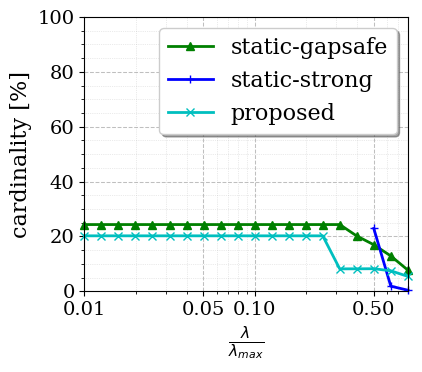

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [33]:
y_lim = (0,100)
x_lim = (np.min(lmb_r), np.max(lmb_r))

fig, ax = plt.subplots(figsize=(4.5,4))

plt.semilogx(lmb_r[red_gsafe_vec], 100*card_mat[1,red_gsafe_vec], color='g', label='static-gapsafe', marker='^', linewidth=2, clip_on=False)
plt.semilogx(lmb_r[red_strong_vec], 100*card_mat[2,red_strong_vec], color='b', label='static-strong', marker='+', linewidth=2, clip_on=False)
plt.semilogx(lmb_r, 100*card_mat[3,:], color='c', label='proposed', marker='x', linewidth=2, clip_on=False)

plt.grid(which='major', linestyle='--', linewidth=0.75, alpha=0.8)
plt.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.5)
plt.minorticks_on()

ax = plt.gca()

ax.xaxis.set_major_locator(FixedLocator(x_ticks))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2,10) * 0.1, numticks=10))

plt.xlim(x_lim)
plt.ylim(y_lim)

plt.legend(fancybox=True, shadow=True)
plt.xlabel(r"$\frac{\lambda}{\lambda_{max}}$")
plt.ylabel("cardinality [%]")

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()

fig.savefig('../results/adrenalmnist3d-cardinality.eps', format='eps', bbox_inches='tight')

## Processing time

In [ ]:
y_lim = (0,3)
x_lim = (np.min(lmb_r), np.max(lmb_r))

fig, ax = plt.subplots(figsize=(4.5,4))

plt.semilogx(lmb_r, time_mat[0,:], color='r', label='vanilla', marker='o', linewidth=2, clip_on=False)
plt.semilogx(lmb_r[red_gsafe_vec], time_mat[1,red_gsafe_vec], color='g', label='static-gapsafe', marker='^', linewidth=2, clip_on=False)
plt.semilogx(lmb_r[red_strong_vec], time_mat[2,red_strong_vec], color='b', label='static-strong', marker='+', linewidth=2, clip_on=False)
plt.semilogx(lmb_r, time_mat[3,:], color='c', label='proposed', marker='x', linewidth=2, clip_on=False)

plt.grid(which='major', linestyle='--', linewidth=0.75, alpha=0.8)
plt.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.5)
plt.minorticks_on()

ax = plt.gca()

ax.xaxis.set_major_locator(FixedLocator(x_ticks))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2,10)*0.1, numticks=10))

plt.xlim(x_lim)
plt.ylim(y_lim)

plt.legend(fancybox=True, shadow=True)
plt.xlabel(r"$\frac{\lambda}{\lambda_{max}}$")
plt.ylabel("time [s]")

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()

fig.savefig('../results/adrenalmnist3d-time.eps', format='eps', bbox_inches='tight')

## Speedup

In [ ]:
y_lim = (1,60)
x_lim = (np.min(lmb_r), np.max(lmb_r))

fig, ax = plt.subplots(figsize=(4.5,4))

plt.semilogx(lmb_r[red_gsafe_vec], (time_mat[0,red_gsafe_vec]/time_mat[1,red_gsafe_vec]), color='g', label='static-gapsafe', marker='^', linewidth=2, clip_on=False)
plt.semilogx(lmb_r[red_strong_vec], (time_mat[0,red_strong_vec]/time_mat[2,red_strong_vec]), color='b', label='static-strong', marker='+', linewidth=2, clip_on=False)
plt.semilogx(lmb_r, (time_mat[0,:]/time_mat[3,:]), color='c', label='proposed', marker='x', linewidth=2, clip_on=False)

plt.grid(which='major', linestyle='--', linewidth=0.75, alpha=0.8)
plt.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.5)
plt.minorticks_on()

ax = plt.gca()

ax.xaxis.set_major_locator(FixedLocator(x_ticks))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2,10)*0.1, numticks=10))

plt.xlim(x_lim)
plt.ylim(y_lim)

plt.legend(fancybox=True, shadow=True)
plt.xlabel(r"$\frac{\lambda}{\lambda_{max}}$")
plt.ylabel("speedup")

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()

fig.savefig('../results/adrenalmnist3d-speedup.eps', format='eps', bbox_inches='tight')

## Accuracy

In [ ]:
y_lim = (0,1)
x_lim = (np.min(lmb_r), np.max(lmb_r))

fig, ax = plt.subplots(figsize=(4.5, 4))

plt.semilogx(lmb_r, acc_train_mat[0,:], color='m', label='train set', linewidth=2, clip_on=False)#, marker='o')
plt.semilogx(lmb_r, acc_train_mat[1,:], color='m', linewidth=2, clip_on=False)#, marker='o')
plt.semilogx(lmb_r, acc_train_mat[2,:], color='m', linewidth=2, clip_on=False)
plt.semilogx(lmb_r, acc_train_mat[3,:], color='m', linewidth=2, clip_on=False)#, marker='o')

plt.semilogx(lmb_r, acc_test_mat[0,:], color='y', label='test set', linewidth=2, clip_on=False)#, marker='o')
plt.semilogx(lmb_r, acc_test_mat[1,:], color='y', linewidth=2, clip_on=False)#, marker='o')
plt.semilogx(lmb_r, acc_test_mat[2,:], color='y', linewidth=2, clip_on=False)
plt.semilogx(lmb_r, acc_test_mat[3,:], color='y', linewidth=2, clip_on=False)#, marker='o')

plt.grid(which='major', linestyle='--', linewidth=0.75, alpha=0.8)
plt.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.5)
plt.minorticks_on()

ax = plt.gca()

ax.xaxis.set_major_locator(FixedLocator(x_ticks))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))

plt.xlim(x_lim)
plt.ylim(y_lim)

plt.legend(loc='lower left', fancybox=True, shadow=True)
plt.xlabel(r"$\frac{\lambda}{\lambda_{max}}$")
plt.ylabel("accuracy")

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()

fig.savefig('../results/adrenalmnist3d-acc.eps', format='eps', bbox_inches='tight')